In [21]:
#import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt2
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



In [3]:
df1 = pd.read_csv('firstrealFinal.csv', usecols=[0,1,2,3,4])
df2 = pd.read_csv('secondrealFinal.csv', usecols=[0,1,2,3,4])
cols =  ["time", "rsp", "ppg", "ecg","eda"]
df1.columns = cols
df2.columns = cols
print(df1.head())
print(df2.head())

arr1 = df1.to_numpy()
arr2 = df2.to_numpy()


     time      rsp       ppg       ecg       eda
0  0.0005  5.32043 -0.014343 -0.004730 -0.004578
1  0.0010  5.32104 -0.014648 -0.004883 -0.003052
2  0.0015  5.31982 -0.014648 -0.004730 -0.003052
3  0.0020  5.32013 -0.014648 -0.004883 -0.004578
4  0.0025  5.32013 -0.014648 -0.004883 -0.004578
     time      rsp       ppg       ecg           eda
0  0.0005  6.25854  0.336914  0.058289  1.526070e-03
1  0.0010  6.25854  0.336304  0.059357  1.526070e-03
2  0.0015  6.25885  0.333862  0.060272  1.526070e-03
3  0.0020  6.25885  0.332336  0.060883  3.051940e-03
4  0.0025  6.25885  0.332031  0.060730  1.862670e-07


In [4]:
arr1time = arr1[:,0]
arr1rsp = arr1[:,1]
arr1ppg = arr1[:,2]
arr1ecg = arr1[:,3]
arr1eda = arr1[:,4]

arr2time = arr2[:,0]
arr2rsp = arr2[:,1]
arr2ppg = arr2[:,2]
arr2ecg = arr2[:,3]
arr2eda = arr2[:,4]

print(arr1time)
print(arr2time)

[5.00000e-04 1.00000e-03 1.50000e-03 ... 1.63326e+02 1.63327e+02
 1.63327e+02]
[5.00000e-04 1.00000e-03 1.50000e-03 ... 1.64798e+02 1.64799e+02
 1.64799e+02]


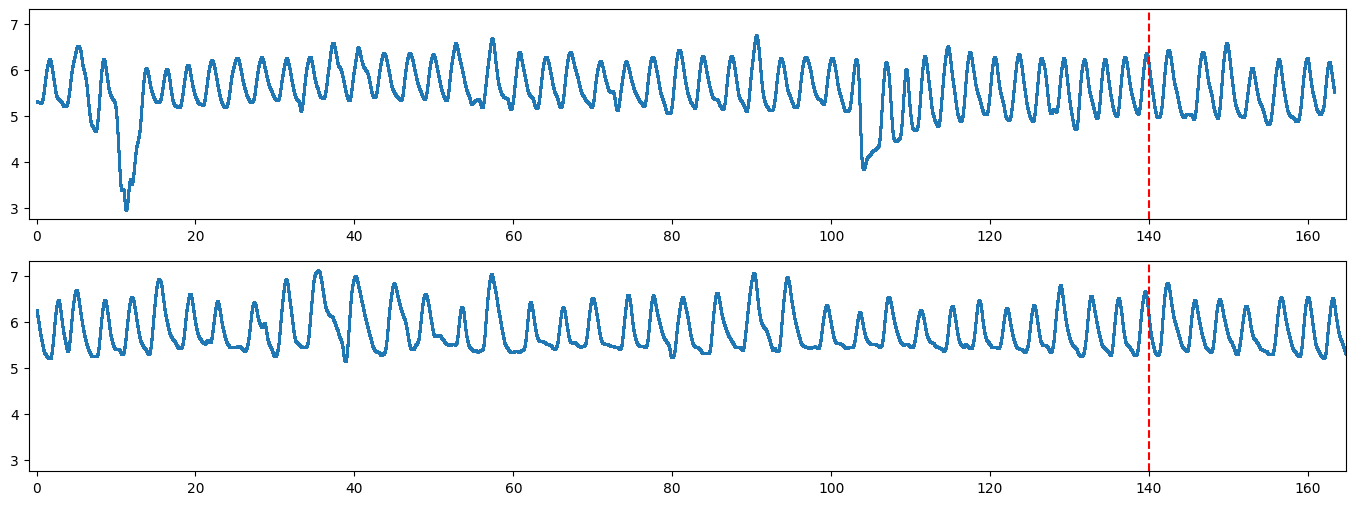

In [5]:
ymin = min(arr1rsp.min(), arr2rsp.min()) - 0.2
ymax = max(arr1rsp.max(), arr2rsp.max()) +0.2

plt.figure(figsize=(17, 6))

plt.subplot(2, 1, 1)
plt.scatter(arr1time, arr1rsp, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')


plt.subplot(2, 1, 2)
plt.scatter(arr2time, arr2rsp, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')

plt.show()

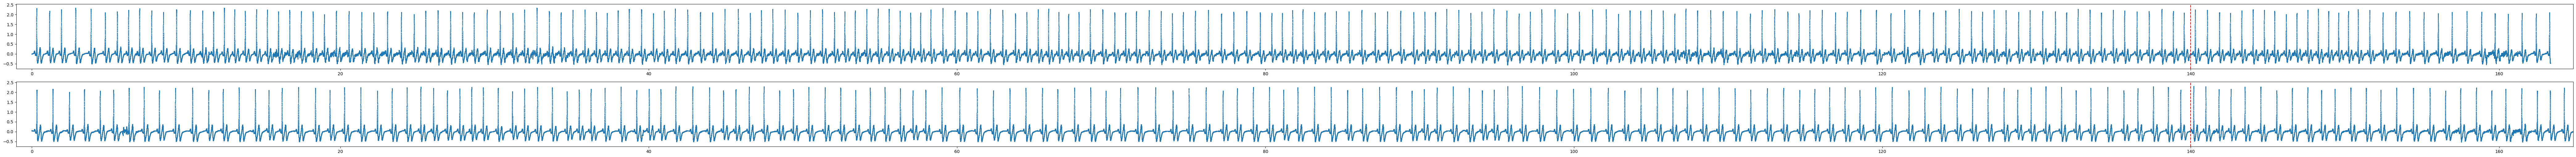

In [15]:
ymin = min(arr1ecg.min(), arr2ecg.min()) - 0.2
ymax = max(arr1ecg.max(), arr2ecg.max()) +0.2

plt.figure(figsize=(107, 6))

plt.subplot(2, 1, 1)
plt.scatter(arr1time, arr1ecg, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')


plt.subplot(2, 1, 2)
plt.scatter(arr2time, arr2ecg, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')

plt.show()

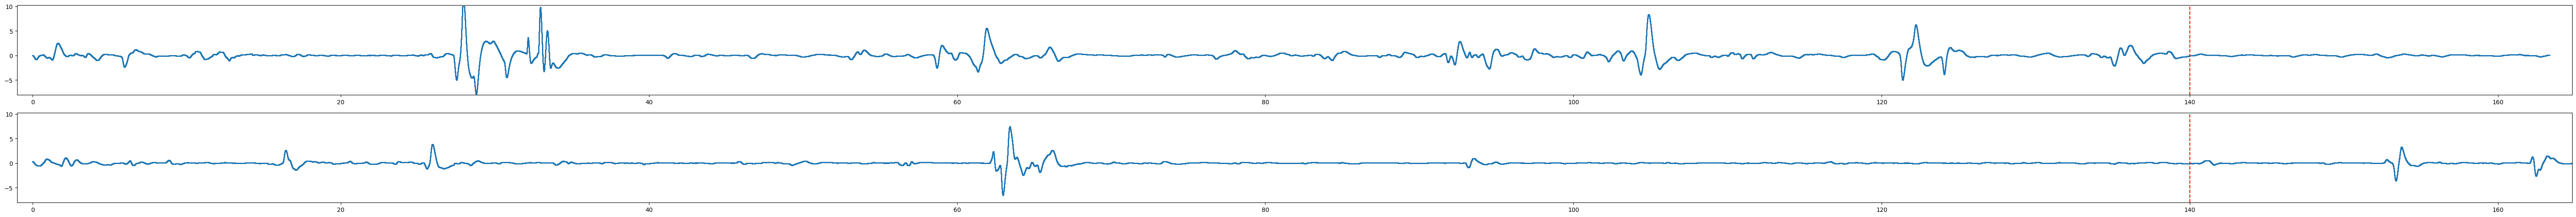

In [36]:
ymin = min(arr1ppg.min(), arr2ppg.min()) - 0.2
ymax = max(arr1ppg.max(), arr2ppg.max()) +0.2

plt.figure(figsize=(77, 6))

plt.subplot(2, 1, 1)
plt.scatter(arr1time, arr1ppg, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')


plt.subplot(2, 1, 2)
plt.scatter(arr2time, arr2ppg, s=1)
plt.ylim(ymin, ymax)
plt.xlim(-1, max(arr1time.max(), arr2time.max()))
plt.axvline(x=140, color='r', linestyle='--')

plt.show()

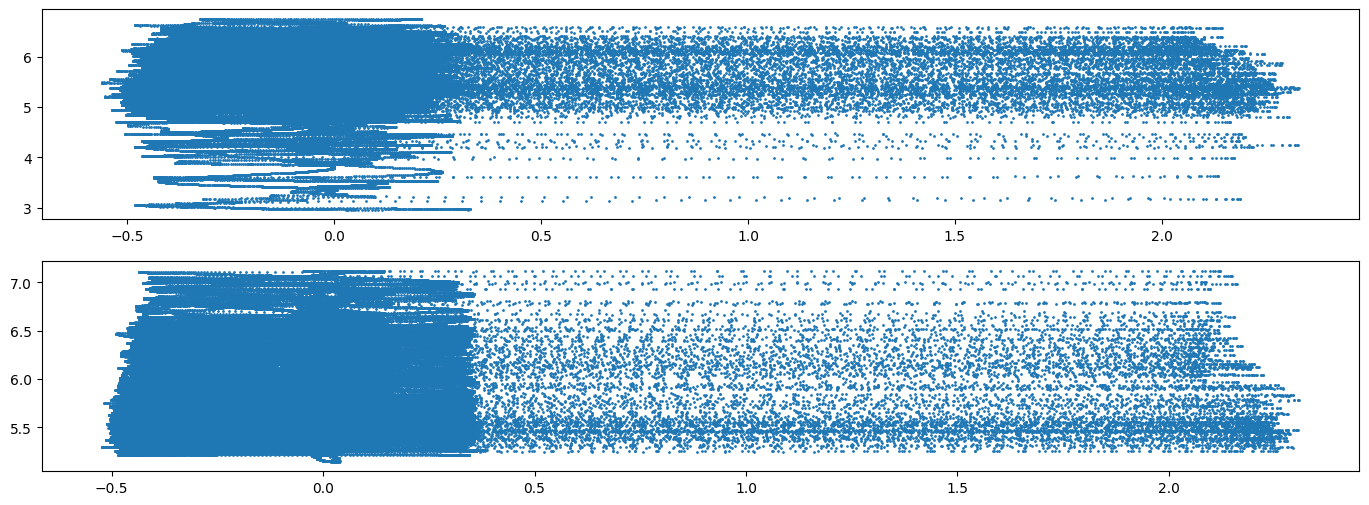

In [11]:
plt.figure(figsize=(17, 6))
plt.subplot(2, 1, 1)
plt.scatter(arr1ecg, arr1rsp, label='First Real', s=1)
plt.subplot(2, 1, 2)
plt.scatter(arr2ecg, arr2rsp, label='Second Real', s=1)

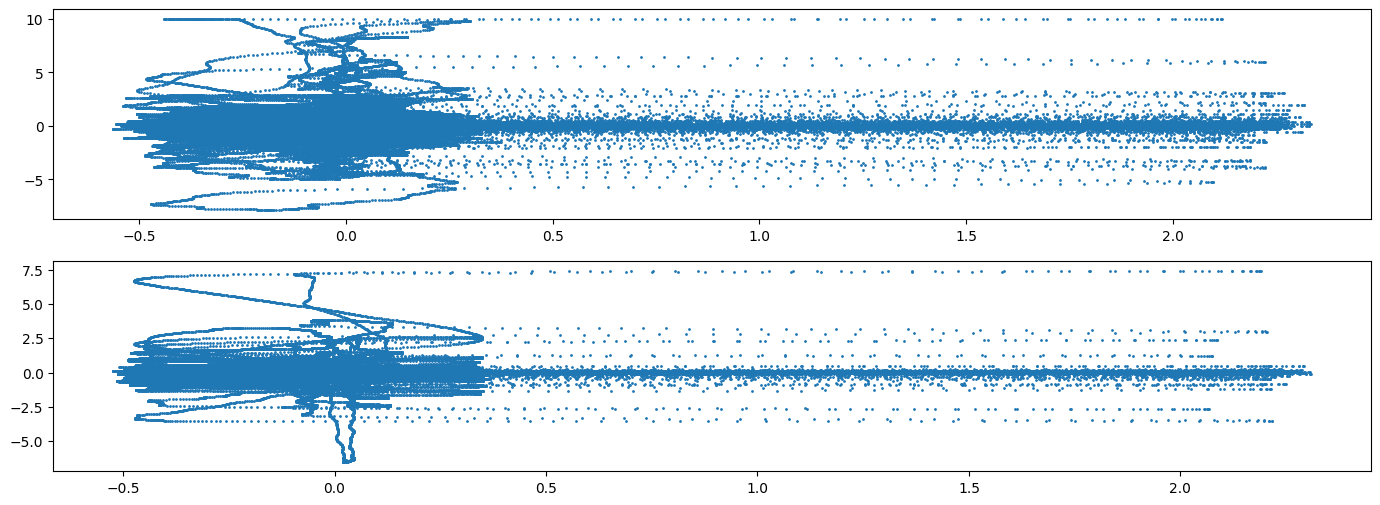

In [12]:
plt.figure(figsize=(17, 6))
plt.subplot(2, 1, 1)
plt.scatter(arr1ecg, arr1ppg, label='First Real', s=1)
plt.subplot(2, 1, 2)
plt.scatter(arr2ecg, arr2ppg, label='Second Real', s=1)

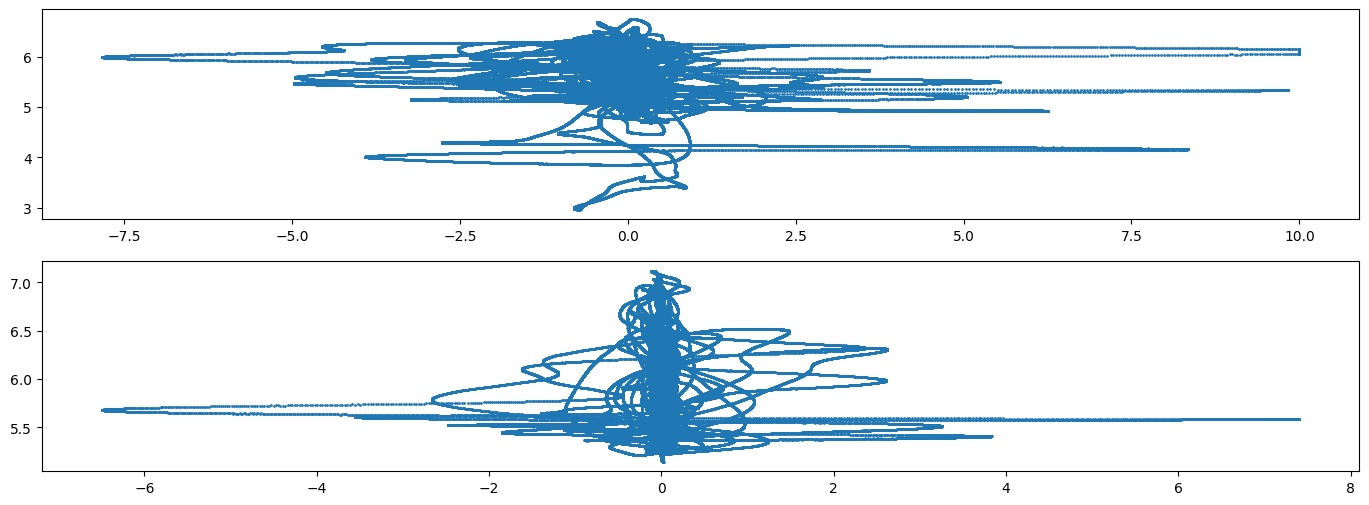

In [13]:
plt.figure(figsize=(17, 6))
plt.subplot(2, 1, 1)
plt.scatter(arr1ppg, arr1rsp, label='First Real', s=1)
plt.subplot(2, 1, 2)
plt.scatter(arr2ppg, arr2rsp, label='Second Real', s=1)

In [14]:
arrecg = np.concatenate((arr1ecg, arr2ecg))
arrppg = np.concatenate((arr1ppg, arr2ppg))
arrrsp = np.concatenate((arr1rsp, arr2rsp))

In [52]:
X = np.stack((arrecg, arrrsp))
print(X)
Y = arrppg
print(Y)

xtrain, xtest, ytrain, ytest = train_test_split(X.T, Y, test_size=0.1, random_state=None)

[[-4.73022e-03 -4.88281e-03 -4.73022e-03 ...  1.02234e-02  1.17493e-02
   1.23596e-02]
 [ 5.32043e+00  5.32104e+00  5.31982e+00 ...  5.30151e+00  5.30090e+00
   5.30151e+00]]
[-0.0143433 -0.0146484 -0.0146484 ... -0.0335693 -0.0338745 -0.0341797]


In [54]:
regr = linear_model.LinearRegression()
regr.fit(xtrain, ytrain)
print(xtest[0:1])
print(regr.predict(xtest[0:1]))

[[0.114746 4.92126 ]]
[0.14031514]


In [55]:
def checkValidity(ecg, rsp, ppg):
    pred = regr.predict([[ecg, rsp]])
    print(pred)
    if abs(pred - ppg) < 0.1:
        return 1
    else:
        return 0

In [56]:
correct = 0
for i in range(xtest.shape[0]):
    correct += checkValidity(xtest[i][0], xtest[i][1], ytest[i])


[0.14031514]
[0.06353181]
[0.06338148]
[-0.01718955]
[0.0784626]
[0.03933869]
[0.08129213]
[0.02483304]
[0.08900091]
[0.02060142]
[0.01591113]
[0.16938252]
[0.0379043]
[0.05915583]
[-0.07579254]
[-0.07060016]
[0.04252954]
[-0.00038852]
[-0.09373299]
[-0.06918328]
[0.03534654]
[0.06106345]
[-0.00898339]
[-0.03143554]
[0.10548646]
[-0.00021759]
[0.05898702]
[-0.04926458]
[0.08151622]
[0.01131631]
[0.08091511]
[0.06260565]
[-0.02156117]
[0.0952555]
[-0.02309785]
[0.11096247]
[0.08546385]
[0.10768013]
[0.0540686]
[0.04292266]
[0.0579095]
[-0.02933772]
[-0.06875242]
[-0.04973102]
[-0.00218793]
[-0.05346309]
[0.05068434]
[0.0739039]
[-0.04037836]
[0.18910871]
[-0.13701903]
[0.01751876]
[-0.08991458]
[0.10580094]
[-0.04440868]
[-0.02049859]
[-0.05409244]
[0.12588268]
[0.04402997]
[0.03585671]
[-0.03958258]
[-0.02681833]
[0.05555592]
[0.04316541]
[0.01605889]
[-0.06538613]
[0.01193845]
[-0.05283666]
[0.05814099]
[0.10368263]
[-0.02244118]
[-0.04115027]
[-0.03980351]
[0.07286794]
[0.09315178]
[

In [57]:
print(correct/xtest.shape[0])

0.5151464358638345
